# Evidencia de apredizaje 2:Proceso de limpieza y de transformación de datos.

**Inflación canasta de alimentos básicos en algunos páises de latinoamerica**

**Integrantes:**

*   Juan Fernando Cataño Higuita
*   Oscar Javier García García
*   Rober Andrés Castillo Gaviria
*   Juan David Ramírez García

**Docente**:

*   Andrés Felipe Palacios

**Institución Universitaria Dígital de antioquia**





In [121]:
## 0.Importación de liberías

import pandas as pd           # Para manipulación de DataFrames
import numpy as np            # Para operaciones numéricas
import matplotlib.pyplot as plt # Para crear gráficos
import seaborn as sns         # Para gráficos estadísticos más atractivos


In [122]:
## 1. Carga del dataset

# Cargamos el dataset desde la URL de Google Sheets utilizada en el proyecto anterior
file_path="https://docs.google.com/spreadsheets/d/e/2PACX-1vQHiBq4hJEg89OqZwvtHYb1pCKtpOUGznbl4FKqyWMXuVzlgH526q71lnb8ShQSBk-50YFWT-AYMLR9/pub?gid=1722424764&single=true&output=csv"

try:
    # Cargando dataset en formato "utf-8"
    df = pd.read_csv(file_path, sep=',', encoding='utf-8')
    print("Archivo cargado con éxito:")
    print(df.head(2))

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró.")

except pd.errors.EmptyDataError:
    print("Error: El archivo está vacío.")

except pd.errors.ParserError:
    print("Error: Fallo en el formato (delimitador o columnas incorrectas).")

except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")


Archivo cargado con éxito:
       City        Country ISO_Country_Code         Region      Continent  \
0  New York  United States              USA  North America  North America   
1  New York  United States              USA  North America  North America   

     Month     Month_Name            Item Item_Key Item_Category  ...  \
0  2025-10   October 2025  Milk (1 Liter)  Milk_1L         Dairy  ...   
1  2025-11  November 2025  Milk (1 Liter)  Milk_1L         Dairy  ...   

                         Inflation_Source FAO_Index_Value  FAO_Index_Date  \
0  USDA Food Price Outlook / IMF WEO 2026           127.1    October 2025   
1  USDA Food Price Outlook / IMF WEO 2026           126.2   November 2025   

  FAO_YoY_Change_Pct  USDA_All_Food_Forecast_Pct  USDA_Food_At_Home_Pct  \
0               -1.0                         3.1                    2.5   
1               -1.0                         3.1                    2.5   

   Data_Collection_Date                                      So

In [123]:
## 2. Filtramos inmediatamente para Colombia, ya que es nuestro foco de análisis
df_col = df[df['Country'] == 'Colombia'].copy()

print(f"Dataset original cargado exitosamente.")
print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas")
print(f"\nSubconjunto de Colombia creado.")
print(f"Dimensiones: {df_col.shape[0]} filas y {df_col.shape[1]} columnas")
print("\nPrimeras filas del subconjunto de Colombia:")
df_col.head()

Dataset original cargado exitosamente.
Dimensiones: 10248 filas y 27 columnas

Subconjunto de Colombia creado.
Dimensiones: 168 filas y 27 columnas

Primeras filas del subconjunto de Colombia:


,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,Inflation_Source,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD
8148,Bogota,Colombia,COL,Latin America,South America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,IMF WEO 2026,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/Bogota,7181469,7.22
8149,Bogota,Colombia,COL,Latin America,South America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,IMF WEO 2026,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/Bogota,7181469,7.46
8150,Bogota,Colombia,COL,Latin America,South America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,IMF WEO 2026,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/Bogota,7181469,7.64
8151,Bogota,Colombia,COL,Latin America,South America,2026-01,January 2026,Milk (1 Liter),Milk_1L,Dairy,...,IMF WEO 2026,124.2,January 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/Bogota,7181469,7.40
8152,Bogota,Colombia,COL,Latin America,South America,2026-02,February 2026,Milk (1 Liter),Milk_1L,Dairy,...,IMF WEO 2026,125.3,February 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/Bogota,7181469,7.51


## **1. Descripción e Identificación de las necesidades de Limpieza**

In [124]:
### 3. Filtrando Variables Relevantes para el análisis
variables_clave = ['City', 'Month', 'Item', 'Item_Category','Item_Key', 'Price_Local','Price_USD','FAO_Index_Value','FAO_YoY_Change_Pct','YoY_Inflation_Estimate_Pct', 'Data_Collection_Date','Breakfast_Basket_USD']
df_col = df_col[variables_clave]
print(f"Seleccionando variables relevantes para el análisis: {variables_clave}")

Seleccionando variables relevantes para el análisis: ['City', 'Month', 'Item', 'Item_Category', 'Item_Key', 'Price_Local', 'Price_USD', 'FAO_Index_Value', 'FAO_YoY_Change_Pct', 'YoY_Inflation_Estimate_Pct', 'Data_Collection_Date', 'Breakfast_Basket_USD']


In [125]:
## 4. Identificamos necesidades de Limpieza

print("--- Reporte de necesidades del limpieza ---")

# 1. Duplicados
print(f"\n--------Evaluando duplicados...\n")
total_duplicados = df_col.duplicated().sum()
print(f"El numero de filas duplicadas en el dataset es: {total_duplicados}.")

# 2. Valores Nulos
print(f"\n--------Evaluando valores nulos...\n")
# Calcula el total de valores nulos en el DataFrame df_col
total_nulos = df_col.isnull().sum().sum()
# Calcula el total de celdas en el DataFrame df_col
total_celdas = df_col.shape[0] * df_col.shape[1]
# Calcula la proporción total de valores nulos en df_col
proporcion_total_nulos = (total_nulos / total_celdas) * 100
print(f"Total de {total_nulos} valores nulos, la porción de datos nulos es {proporcion_total_nulos:.2f}%\n")

# 3. Inconsistencias en Valores (Categorías y Texto)
print(f"\n--------Evaluando inconsistencias en valores...\n")
for i in variables_clave:
  print(f"Aplicando value_counts() a las siguientes columnas: {i}\n")
  print(df_col[i].value_counts())

# 4. Tipos de Datos
print(f"\n--------Evaluando tipos de datos...\n")
print("Verificando si los tipos de datos asignados son los correctos...")
for i in variables_clave:
    print(f"La columna '{i}' está definida como tipo {df_col[i].dtype}.")

# 5. Valores Atípicos (Outliers)
print(f"\n--------Evaluando valores atípicos...\n")
# Usando el método IQR para columnas numéricas
numericas = df_col.select_dtypes(include=[np.number]).columns
for col in numericas:
    Q1 = df_col[col].quantile(0.25)
    Q3 = df_col[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_col[(df_col[col] < (Q1 - 1.5 * IQR)) | (df_col[col] > (Q3 + 1.5 * IQR))].shape[0]
    print(f"Evaluando valores atípicos en '{col}': identificando {outliers} registros que podrían distorsionar el análisis estadístico.")

# 6. Granularidad
print(f"\n--------Evaluando granularidad...\n")

# Definimos las dimensiones reales que identifican un dato
dimensiones_identidad = ['City', 'Month', 'Item']

# Calculamos la granularidad
# (Contamos cuántos precios existen para cada combinación de Ciudad-Mes-Producto)
analisis_grano = df.groupby(dimensiones_identidad).size()
max_detalle = analisis_grano.max()

print(f"DEBUG: El máximo de registros por combinación es: {max_detalle}")

if max_detalle > 1:
    print("ALTA GRANULARIDAD: Tienes varios precios para el mismo producto el mismo mes.")
    print("ACCIÓN: Calcula la variabilidad interna (dispersión de precios en el mismo mes).")
    # Ejemplo: ¿Por qué hay dos precios de leche en Bogotá en Octubre? (Diferentes tiendas)
    resultado = df.groupby(dimensiones_identidad)['Price_USD'].std()
else:
    print("BAJA GRANULARIDAD: Solo hay un precio oficial por mes/ciudad.")
    print("ACCIÓN: Calcula la variabilidad temporal (cómo cambia el precio mes a mes).")
    # Ejemplo: ¿Cuánto subió la leche de Octubre a Noviembre en Bogotá?
    df_sorted = df.sort_values(by=dimensiones_identidad)
    df_sorted['Variacion_Mensual'] = df_sorted.groupby(['City', 'Item'])['Price_USD'].pct_change()
    print(df_sorted[['City', 'Month', 'Item', 'Variacion_Mensual']].dropna().head())



--- Reporte de necesidades del limpieza ---

--------Evaluando duplicados...

El numero de filas duplicadas en el dataset es: 0.

--------Evaluando valores nulos...

Total de 0 valores nulos, la porción de datos nulos es 0.00%


--------Evaluando inconsistencias en valores...

Aplicando value_counts() a las siguientes columnas: City

City
Bogota      84
Medellin    84
Name: count, dtype: int64
Aplicando value_counts() a las siguientes columnas: Month

Month
2025-10    28
2025-11    28
2025-12    28
2026-01    28
2026-02    28
2026-03    28
Name: count, dtype: int64
Aplicando value_counts() a las siguientes columnas: Item

Item
Milk (1 Liter)              12
Fresh White Bread (500g)    12
White Rice (1 kg)           12
Eggs (Regular, 12)          12
Local Cheese (1 kg)         12
Chicken Fillets (1 kg)      12
Beef Round (1 kg)           12
Apples (1 kg)               12
Bananas (1 kg)              12
Oranges (1 kg)              12
Tomatoes (1 kg)             12
Potatoes (1 kg)         

In [126]:
df_col.head()

,City,Month,Item,Item_Category,Item_Key,Price_Local,Price_USD,FAO_Index_Value,FAO_YoY_Change_Pct,YoY_Inflation_Estimate_Pct,Data_Collection_Date,Breakfast_Basket_USD
8148,Bogota,2025-10,Milk (1 Liter),Dairy,Milk_1L,5672.27,1.35,127.1,-1.0,5.9,2026-03-20,7.22
8149,Bogota,2025-11,Milk (1 Liter),Dairy,Milk_1L,5630.25,1.34,126.2,-1.0,5.9,2026-03-20,7.46
8150,Bogota,2025-12,Milk (1 Liter),Dairy,Milk_1L,5714.29,1.36,125.8,-1.0,5.9,2026-03-20,7.64
8151,Bogota,2026-01,Milk (1 Liter),Dairy,Milk_1L,5798.32,1.38,124.2,-1.0,5.9,2026-03-20,7.40
8152,Bogota,2026-02,Milk (1 Liter),Dairy,Milk_1L,5588.24,1.33,125.3,-1.0,5.9,2026-03-20,7.51


### Descripción necesidades de Limpieza de acuerdo al reporte de identifcación de necesidades de limpieza.



*   **Duplicados:** No se encontraron valores duplicados.
*   **Valores Nulos:** No se encontraron valores duplicados.
*   **Inconsistencias en valores**:
    * **City**: Bogota y "Medellin" sin tildes,se vería mejor estandarizado como Bogotá y "Medellín.
    * **Item**: Nombre los items con las unidades de cantidad que son de la la variable Item_key. Estandarizar por ejemplo Milk (1 L) por Milk.
    * **Price_local**: Números decimales Rodendeo a enteros para que sean coherente al peso colombiano.
* **Tipos de datos**: Las variables **Month** y **Data-Collection_date** son de tipo object, transformar a tipo datetime.
* **Valores atipicos y granulidad:** Las variables **Price_Local**y **Price_USD** poseen muchos valores distintos, indicando dispersion y variabilidad de los precios de la canasta.
* **Nivel de granulidad**: La granulidad es baja, se recomeinda calcular la variabilidad por mes



## **2. Limpieza y transformación**

1. **Eliminación de duplicados**: de acuerdo al reporte realizado en el punto anterior no se encontraron valores duplicados, lo cual no es encesario realizar este proceso.

In [127]:
total_duplicados = df_col.duplicated().sum()
print(f"El numero de filas duplicadas en el dataset es: {total_duplicados}.")

El numero de filas duplicadas en el dataset es: 0.


2. **Tratamiento de valores nulos**: De igual forma según el reporte realizado tampoco se encontraron valores nulos, lo cual hace no necesario realizar esta tarea.

In [128]:
total_nulos = df_col.isnull().sum().sum()
print(f"Número de valores nulos en el dataset: {total_nulos}.")

Número de valores nulos en el dataset: 0.


3. **Ajuste de tipo de datos**: Las variables Month y Data-Collection_date son de tipo object, transformar a tipo datetime.

In [129]:
df_col['Month'] = pd.to_datetime(df_col['Month'], format='%Y-%m')
df_col['Data_Collection_Date'] = pd.to_datetime(df_col['Data_Collection_Date'])

#Verficando el cambio

print(f"La variable Month es de tipo: {df_col['Month'].dtype}")
print(f"La variable Data_collection_date es de tipo: {df_col['Data_Collection_Date'].dtype}")

La variable Month es de tipo: datetime64[ns]
La variable Data_collection_date es de tipo: datetime64[ns]


4. **Detección y Tratamiento de Valores Atípicos** Se detecto que las variables **Price_Local** y **Price_USD** poseen valores atípicos, entonces vamos a realizar boxplots para examniar la variablidad de las mismas.

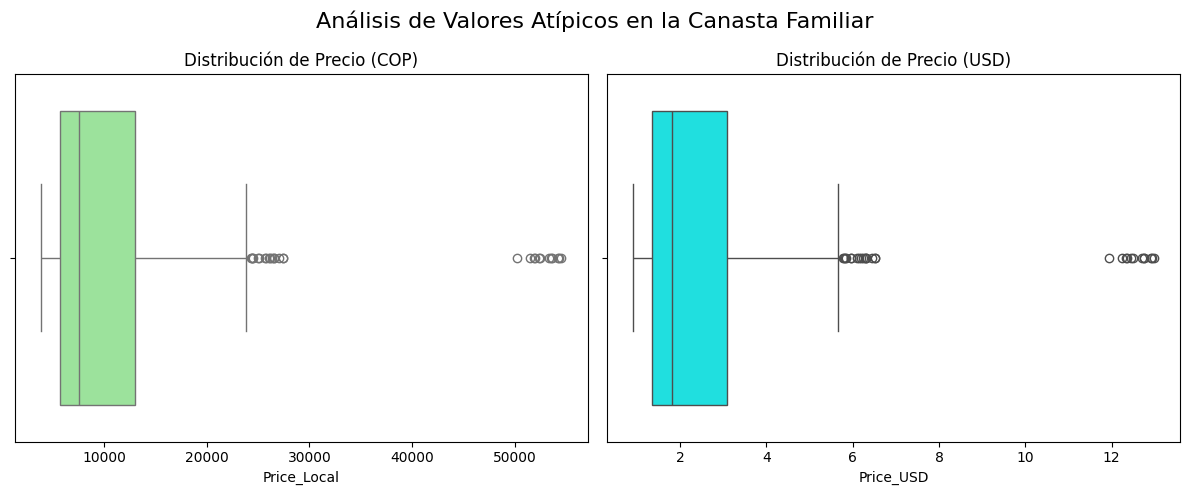

In [130]:
# Graficando boxplots para Price_local y Price_USD
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primer Boxplot: Price_Local
sns.boxplot(data=df_col, x='Price_Local', ax=axes[0], color='lightgreen')
axes[0].set_title('Distribución de Precio (COP)') # Usamos set_title sobre el eje 0

# Segundo Boxplot: Price_USD
sns.boxplot(data=df_col, x='Price_USD', ax=axes[1], color='cyan')
axes[1].set_title('Distribución de Precio (USD)') # Usamos set_title sobre el eje 1

# Título general para toda la figura (opcional pero recomendado)
fig.suptitle('Análisis de Valores Atípicos en la Canasta Familiar', fontsize=16)

plt.tight_layout() # Para que no se amontonen los títulos
plt.show()

/tmp/ipykernel_4071/3162594319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_col, x='Price_Local', y='Item_Category', palette='Set2')


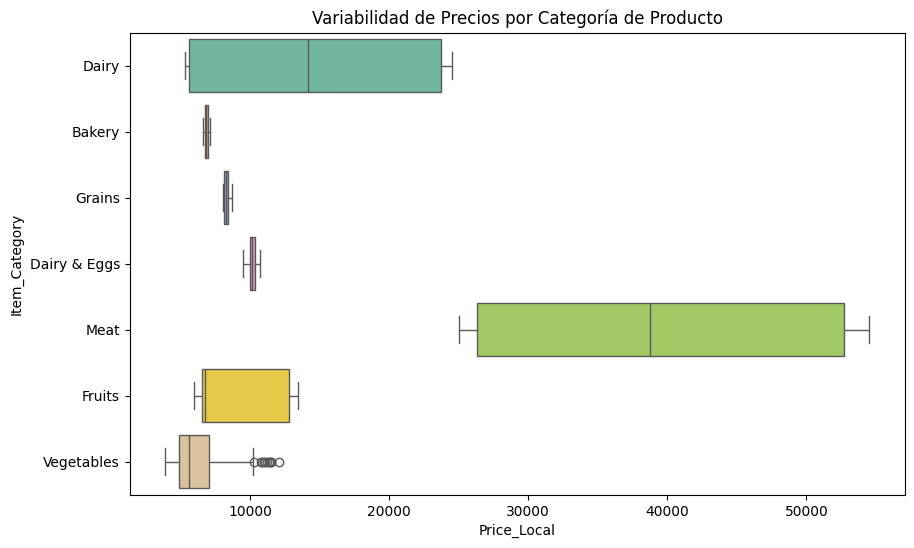

In [131]:
# Graficando los boxplot por categoría
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_col, x='Price_Local', y='Item_Category', palette='Set2')
plt.title('Variabilidad de Precios por Categoría de Producto')
plt.show()

/tmp/ipykernel_4071/904048997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_col, x='Price_USD', y='Item_Category', palette='Set2')


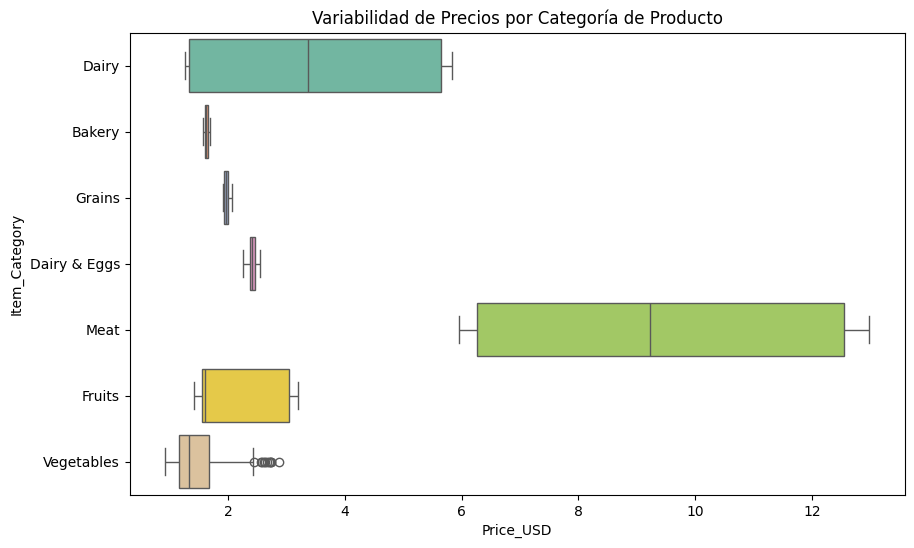

In [132]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_col, x='Price_USD', y='Item_Category', palette='Set2')
plt.title('Variabilidad de Precios por Categoría de Producto')
plt.show()

**No se eliminaran valores atipicos:** Tras analizar la distribución de precios tanto en moneda local como en dólares, se observa que la variabilidad está impulsada por productos específicos, como la carne. Detectando que estos valores atípicos representan la realidad del mercado y no errores de captura, se ha decidido conservarlos; eliminarlos resultaría en una pérdida de información crítica sobre la fluctuación real de los costos en la canasta.

5. **Correcciones de Valores con** `replace`, `map` y `zip`

* Variable **City** se van a estandarizar el nombre de las ciudades
`{'Bogota': 'Bogotá', 'Medellin': 'Medellín'}`

In [133]:
# 1. Corrigiendo Ciudades usando replace con diccionario
ciudades_dict = {'Bogota': 'Bogotá', 'Medellin': 'Medellín'}
df_col['City'] = df_col['City'].replace(ciudades_dict)
print(f"Estandarizando nombres de ciudades: {list(ciudades_dict.values())}.")

Estandarizando nombres de ciudades: ['Bogotá', 'Medellín'].


* Vamos a estandarizar y reducir los nombres de los productos en la variable **item**

In [134]:
# 2. Corrigiendo Items Estandarización y trim usando zip y map
# Creamos las listas de nombres actuales y los nuevos nombres en español
items_actuales = [
    'Milk (1 Liter)', 'Fresh White Bread (500g)', 'White Rice (1 kg)',
    'Eggs (Regular, 12)', 'Local Cheese (1 kg)', 'Chicken Fillets (1 kg)',
    'Beef Round (1 kg)', 'Apples (1 kg)', 'Bananas (1 kg)', 'Oranges (1 kg)',
    'Tomatoes (1 kg)', 'Potatoes (1 kg)', 'Onions (1 kg)', 'Lettuce (1 Head)'
]

items_cortos = [
    'Milk', 'Fresh White Bread', 'Arroz Blanco', 'Eggs', 'Local Chese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Bananas', 'Oranges',
    'Tomatoes', 'Potatoes', 'Onions', 'Lettuce'
]

# Usando zip para crear el diccionario de mapeo
mapa_traduccion = dict(zip(items_actuales, items_cortos))
df_col['Item'] = df_col['Item'].map(mapa_traduccion)
print(f"Estandarizando y simplificando {len(items_cortos)} items de la canasta familiar.")

Estandarizando y simplificando 14 items de la canasta familiar.


* Redondeando precios de la moneda local `Price_Local`

In [135]:
df_col['Price_Local'] = df_col['Price_Local'].round(0).astype(int)
print(f"Redondeando precios locales a números enteros para coherencia con el COP.")

Redondeando precios locales a números enteros para coherencia con el COP.


6. **Agregación de datos**

* **Variación mensual del costo de la canasta**

In [136]:
precio_mensual = df_col.groupby('Month')['Price_Local'].sum().reset_index()
print(f"Calculando el precio mensual total de los productos de la canasta familia.")
precio_mensual

Calculando el precio mensual total de los productos de la canasta familia.


,Month,Price_Local
0,2025-10-01,363320
1,2025-11-01,374706
2,2025-12-01,373865
3,2026-01-01,370461
4,2026-02-01,376555
5,2026-03-01,376974


In [137]:
precio_mensual = df_col.groupby('Month')['Breakfast_Basket_USD'].sum().reset_index()
print(f"Calculando el precio mensual total de los productos de la canasta familia en dolares.")
precio_mensual

Calculando el precio mensual total de los productos de la canasta familia en dolares.


,Month,Breakfast_Basket_USD
0,2025-10-01,199.92
1,2025-11-01,205.10
2,2025-12-01,207.62
3,2026-01-01,204.68
4,2026-02-01,207.34
5,2026-03-01,209.44


* **Comparativa de precios por Ciudad**

In [138]:
# Comparativa de precios por Ciudad mensual
precio_mensual_ciudad= df_col.groupby(['City', 'Month'])[['Price_Local','Price_USD','Breakfast_Basket_USD']].sum().reset_index()
print(f"Calculando el precio mensual total de los productos de la canasta familia por ciudad.")
precio_mensual_ciudad

Calculando el precio mensual total de los productos de la canasta familia por ciudad.


,City,Month,Price_Local,Price_USD,Breakfast_Basket_USD
0,Bogotá,2025-10-01,185463,44.14,101.08
1,Bogotá,2025-11-01,191471,45.57,104.44
2,Bogotá,2025-12-01,190125,45.25,106.96
3,Bogotá,2026-01-01,188360,44.83,103.60
4,Bogotá,2026-02-01,190546,45.35,105.14
5,Bogotá,2026-03-01,192017,45.70,106.68
6,Medellín,2025-10-01,177857,42.33,98.84
7,Medellín,2025-11-01,183235,43.61,100.66
8,Medellín,2025-12-01,183740,43.73,100.66
9,Medellín,2026-01-01,182101,43.34,101.08


* **Costo promedio por categoría**

In [139]:
# Costo promedio por Categoría de Producto
resumen_categoria = df_col.groupby('Item_Category')[['Price_Local','Price_USD']].mean().round(2).sort_values(by='Price_Local', ascending=False).reset_index()
print(f"Agrupando por categorías: identificando qué grupos de alimentos (Carnes, Lácteos, etc.) tienen mayor peso en el presupuesto.")
resumen_categoria

Agrupando por categorías: identificando qué grupos de alimentos (Carnes, Lácteos, etc.) tienen mayor peso en el presupuesto.


,Item_Category,Price_Local,Price_USD
0,Meat,39534.33,9.41
1,Dairy,14655.00,3.49
2,Dairy & Eggs,10171.50,2.42
3,Fruits,8743.11,2.08
4,Grains,8277.00,1.97
5,Bakery,6866.50,1.63
6,Vegetables,6600.10,1.57


In [140]:
# Usamos mean() para la inflación ya que es un valor estático por mes en tus datos
comparativa_inflacion = df_col.groupby('Month')[['Price_Local', 'YoY_Inflation_Estimate_Pct']].mean().reset_index()
print(f"Cruzando datos de inflación: comparando el aumento de precios locales frente al estimado de inflación anual.")
comparativa_inflacion

Cruzando datos de inflación: comparando el aumento de precios locales frente al estimado de inflación anual.


,Month,Price_Local,YoY_Inflation_Estimate_Pct
0,2025-10-01,12975.714286,5.9
1,2025-11-01,13382.357143,5.9
2,2025-12-01,13352.321429,5.9
3,2026-01-01,13230.750000,5.9
4,2026-02-01,13448.392857,5.9
5,2026-03-01,13463.357143,5.9


Podemos observar que mientras la inflación oficial anual es de **5.9%**, los precios reales fluctúan mes a mes. Detectando un aumento de octubre a noviembre y una leve estabilización posterior, confirmamos que la canasta familiar tiene una variabilidad propia que no siempre coincide con las proyecciones estáticas.

## **3. Validación**

1. **Completitud de los datos**

In [141]:
print("="*60)
print(" VALIDACIÓN: COMPLETITUD DE LOS DATOS")
print("="*60)

nulos_df_col = df_col.isnull().sum().sum()
print(f" DataFrame principal (df_col): {nulos_df_col} valores nulos")
if nulos_df_col == 0 :
    print("\n✓ COMPLETITUD VERIFICADA. El DataFrames esta completo.")
else:
    print("\n✗ Se encontraron valores nulos. Revisar el proceso.")

 VALIDACIÓN: COMPLETITUD DE LOS DATOS
 DataFrame principal (df_col): 0 valores nulos

✓ COMPLETITUD VERIFICADA. El DataFrames esta completo.


**2. Relevancia de las variables**

In [142]:
print("\n" + "="*60)
print(" VALIDACIÓN: RELEVANCIA DE LAS VARIABLES")
print("="*60)

variables_clave = ['City', 'Month', 'Item', 'Item_Category','Item_Key', 'Price_Local','Price_USD','FAO_Index_Value','FAO_YoY_Change_Pct','YoY_Inflation_Estimate_Pct', 'Data_Collection_Date','Breakfast_Basket_USD']
variables_faltantes = [col for col in variables_clave if col not in df_col.columns]

if not variables_faltantes:
    print("✓ Todas las columnas críticas para el análisis están presentes:")
    for col in variables_clave:
        print(f"  - {col}")
    print("\n  • Month: Análisis temporal (Oct 2025 - Mar 2026)")
    print("  • City: Comparación entre ciudades colombianas")
    print("  • Item_Category: Identificación de categorías volátiles")
    print("  • Price_USD: Variable principal para métricas de inflación")
    print("  • Breakfast_Basket_USD: Costo total de la canasta")
else:
    print(f"✗ Faltan columnas críticas: {variables_faltantes_faltantes}")

print("\n✓ RELEVANCIA CONFIRMADA.")


 VALIDACIÓN: RELEVANCIA DE LAS VARIABLES
✓ Todas las columnas críticas para el análisis están presentes:
  - City
  - Month
  - Item
  - Item_Category
  - Item_Key
  - Price_Local
  - Price_USD
  - FAO_Index_Value
  - FAO_YoY_Change_Pct
  - YoY_Inflation_Estimate_Pct
  - Data_Collection_Date
  - Breakfast_Basket_USD

  • Month: Análisis temporal (Oct 2025 - Mar 2026)
  • City: Comparación entre ciudades colombianas
  • Item_Category: Identificación de categorías volátiles
  • Price_USD: Variable principal para métricas de inflación
  • Breakfast_Basket_USD: Costo total de la canasta

✓ RELEVANCIA CONFIRMADA.


3. **Granulidad.**

In [143]:
print("\n" + "="*60)
print(" VALIDACIÓN: GRANULARIDAD ADECUADA")
print("="*60)

print("Evaluando la granularidad de los DataFrames finales:")

print("\n  • df_col (Dataset Principal):")
print(f"    - Dimensiones: {df_col.shape}")
print("    - Granularidad: Producto × Ciudad × Mes")
print("    - Adecuado para: Análisis detallados, cálculo de canasta por ciudad")

print("\n✓ GRANULARIDAD ADECUADA para todos los objetivos del análisis.")

print("\n" + "="*60)
print("RESUMEN FINAL DEL PROCESO DE LIMPIEZA")
print("="*60)

acciones = [
    "1. Duplicados: No teniamos",
    "2. Valores Nulos: No teniamos",
    "3. Tipos de Datos: 'Month'→datetime, 'City'/'Item_Category'→category",
    "4. Valores Atípicos: Se mantuvieron explican la variabilidad de los precios 'Price_USD'",
    "5. map(): Nombres de ciudades estandarizados",
    "6. replace(): Método documentado para correcciones puntuales",
    "7. zip(): Actualización de múltiples filas con condiciones",
    "8. groupby(): Agregación por mes y categoría"
]

for accion in acciones:
    print(f"  ✓ {accion}")


 VALIDACIÓN: GRANULARIDAD ADECUADA
Evaluando la granularidad de los DataFrames finales:

  • df_col (Dataset Principal):
    - Dimensiones: (168, 12)
    - Granularidad: Producto × Ciudad × Mes
    - Adecuado para: Análisis detallados, cálculo de canasta por ciudad

✓ GRANULARIDAD ADECUADA para todos los objetivos del análisis.

RESUMEN FINAL DEL PROCESO DE LIMPIEZA
  ✓ 1. Duplicados: No teniamos
  ✓ 2. Valores Nulos: No teniamos
  ✓ 3. Tipos de Datos: 'Month'→datetime, 'City'/'Item_Category'→category
  ✓ 4. Valores Atípicos: Se mantuvieron explican la variabilidad de los precios 'Price_USD'
  ✓ 5. map(): Nombres de ciudades estandarizados
  ✓ 6. replace(): Método documentado para correcciones puntuales
  ✓ 7. zip(): Actualización de múltiples filas con condiciones
  ✓ 8. groupby(): Agregación por mes y categoría


# Enlace GitHub del proyecto integrado: https://github.com/JuanDavidRamirezGarcia/Proyecto-integrado-III-2026-1

# Enlace colab de este notebook: https://colab.research.google.com/drive/1hyvB8uHR6m0wp479gYbiA7Be7vyySZlK?usp=sharing